In [1]:
import os
os.chdir(os.path.join(os.getcwd(), '..'))
os.getcwd()


'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [2]:
from src.components.optuna_model_selection.lightning_modules import MRIDataModule, MRIModule
from src.constants.local import *
from src.components.optuna_model_selection.model import MRIFlexAttentionUNet, MRIFlexAttentionUNetGroupNorm

In [3]:
import torch
import torch.nn as nn
from torchvision.transforms import v2

In [13]:
state_dict = torch.load('last (3).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict = {
    k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
}

In [42]:
main_model = MRIFlexAttentionUNet(3,64,3,4,1,1,[5,3,3,5,3,5,3,3])
main_model.load_state_dict(inner_state_dict)
dataset = MRIDataModule(TRAIN_CSV, DEV_CSV, TEST_CSV, batch_size = 16, num_workers=10, train_empty_mri_ratio= 1,
                        dev_transform=v2.Compose([
            v2.Resize(256),
            v2.CenterCrop(256)
            ]))
dataset.setup()
dataloader = dataset.val_dataloader()



In [35]:

class F1Calibrator(nn.Module):
    """Learns per-channel scale + bias on logits from a frozen model,
    optimized against a differentiable soft-F1 surrogate."""
    def __init__(self, num_channels=3):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))

    def forward(self, logits):
        # logits: (B, C, H, W) from the frozen main model
        adjusted = logits * self.scale.view(1, -1, 1, 1) + self.bias.view(1, -1, 1, 1)
        return torch.sigmoid(adjusted)

def soft_f1_loss(probs, targets, eps=1e-7):
    # probs, targets: (B, C, H, W) -> per-channel soft F1, then mean over channels
    probs = probs.flatten(2)      # (B, C, N)
    targets = targets.flatten(2).float()

    tp = (probs * targets).sum(dim=(0, 2))
    fp = (probs * (1 - targets)).sum(dim=(0, 2))
    fn = ((1 - probs) * targets).sum(dim=(0, 2))

    soft_f1 = 2 * tp / (2 * tp + fp + fn + eps)   # (C,)
    return 1 - soft_f1.mean()

In [47]:
import numpy as np

In [49]:
main_model.eval()
for p in main_model.parameters():
    p.requires_grad_(False)

calibrator = F1Calibrator(num_channels=3)
optimizer = torch.optim.Adam(calibrator.parameters(), lr=1e-4)
losses_max = []

for i in range(1):
    for j, batch in enumerate(dataloader):  
        images,  masks = batch
        if torch.sum(masks) == 0:
            with torch.no_grad():
                logits = main_model(images)
            #probs = calibrator(logits)
            probs = torch.sigmoid(logits)
            #loss = torch.sum(probs)/len(probs.view(-1))
            #loss = soft_f1_loss(probs, masks)
            loss = torch.max(probs)
        
        
        #optimizer.zero_grad()
        #loss.backward()
        #optimizer.step()
        
            losses_max.append(loss)
        
        print(j)
        #losses.append(loss)
    #print(np.sum(losses)/len(losses))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [ ]:
k = 0
for j, batch in enumerate(dataloader):  
    if j < 10:
        image, mask = batch
        print(image.shape, mask.shape)
    

torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])


In [45]:
len(losses)

49

In [48]:
np.mean(losses)

np.float32(0.0016999969)

In [52]:
import pandas as pd
df = pd.read_csv(DEV_CSV)
len(df[df.empty_slice])/len(df)

0.5682870370370371

In [53]:
max(losses_max)

tensor(1.0000)

In [54]:
min(losses_max)

tensor(5.4237e-07)

In [55]:
np.mean(losses_max)

np.float32(0.28497937)

In [ ]:
tp = out*mask
fn = out * (1- mask)

array([[[ 3, 25,  3],
        [ 3, 25,  3]],

       [[ 3, 25,  3],
        [ 3, 25,  3]]])

In [ ]:
[0,1,1]

False

In [265]:
def get_distribution(model, dataloader):

    num_channels = 3

    dist_pos = np.zeros((num_channels, 100001), dtype=np.int64)  
    dist_neg = np.zeros((num_channels, 100001), dtype=np.int64)  

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            inp, mask = batch
            out = torch.sigmoid(model(inp))  

            for c in range(num_channels):
                probs_c = out[:, c].reshape(-1)
                mask_c = mask[:, c].reshape(-1)

                pos_vals = probs_c[mask_c == 1]
                neg_vals = probs_c[mask_c == 0]

                pos_bins = (pos_vals * 100000).round().type(torch.int64).cpu().numpy()
                neg_bins = (neg_vals * 100000).round().type(torch.int64).cpu().numpy()

                dist_pos[c] += np.bincount(pos_bins, minlength=100001)
                dist_neg[c] += np.bincount(neg_bins, minlength=100001)
            print(i)

    return dist_pos, dist_neg

In [266]:
dist_pos, dist_neg = get_distribution(main_model, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [70]:
10e3+1

10001.0

In [81]:
import matplotlib.pyplot as plt


In [9]:
from scipy.ndimage import gaussian_filter1d

def plot_smooth_distributions(dist_pos, dist_neg, sigma=50, left_x_lim = 0, right_x_lim = 1, threshold = None):
    
    x = np.linspace(0, 1, 100001)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    channel_names = ['small bowel', 'large bowel', 'stomach']
    #rat = np.max(dist_pos, 1)/np.max(dist_neg, 1)
    #dist_neg = dist_neg * rat[:, None]
    for c in range(3):
        ax = axes[c]
        if sigma == 0:
            smooth_pos = dist_pos[c].astype(float)
            smooth_neg = dist_neg[c].astype(float)

        else:
            smooth_pos = gaussian_filter1d(dist_pos[c].astype(float), sigma=sigma)
            smooth_neg = gaussian_filter1d(dist_neg[c].astype(float), sigma=sigma)
        
        # 2. Plot the solid outer lines
        ax.plot(x, smooth_pos, label='Foreground', color='red', linewidth=2)
        ax.plot(x, smooth_neg, label='Background', color='blue', linewidth=2)
        if threshold is not None:
            ax.axvline(x = threshold[c], label = 'Threshold', color = 'green', linewidth = 1)
        
        # 3. Fill the area underneath the curves for readability
        ax.fill_between(x, smooth_pos, alpha=0.2, color='red')
        ax.fill_between(x, smooth_neg, alpha=0.2, color='blue')
        
        # Formatting
        ax.set_title(f'{channel_names[c]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Probability', fontsize=12)
        ax.set_ylabel('Smoothed Pixel Count', fontsize=12)
        
        # Keep the log scale to view massive background counts and tiny foreground counts simultaneously
        ax.set_yscale('log')
        ax.set_xlim(left_x_lim, right_x_lim)
        
        # Force the bottom limit to 1 to prevent log(0) visual artifacts at the bottom of the chart
        ax.set_ylim(bottom=1) 
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best')
        
    plt.tight_layout()
    plt.show()

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002527F12EFC0>
Traceback (most recent call last):
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1650, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002527F12EFC0>
Traceback (most recent call last):
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site

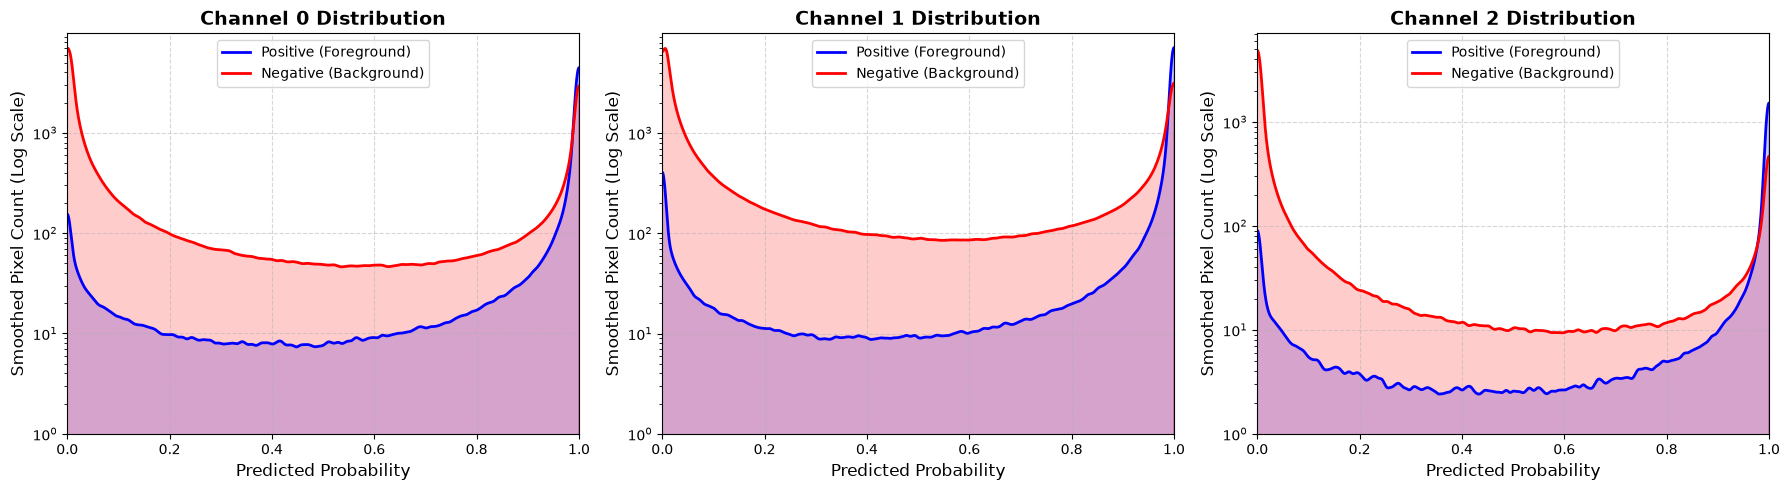

In [ ]:
#plot_smooth_distributions(dist_pos, dist_neg)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

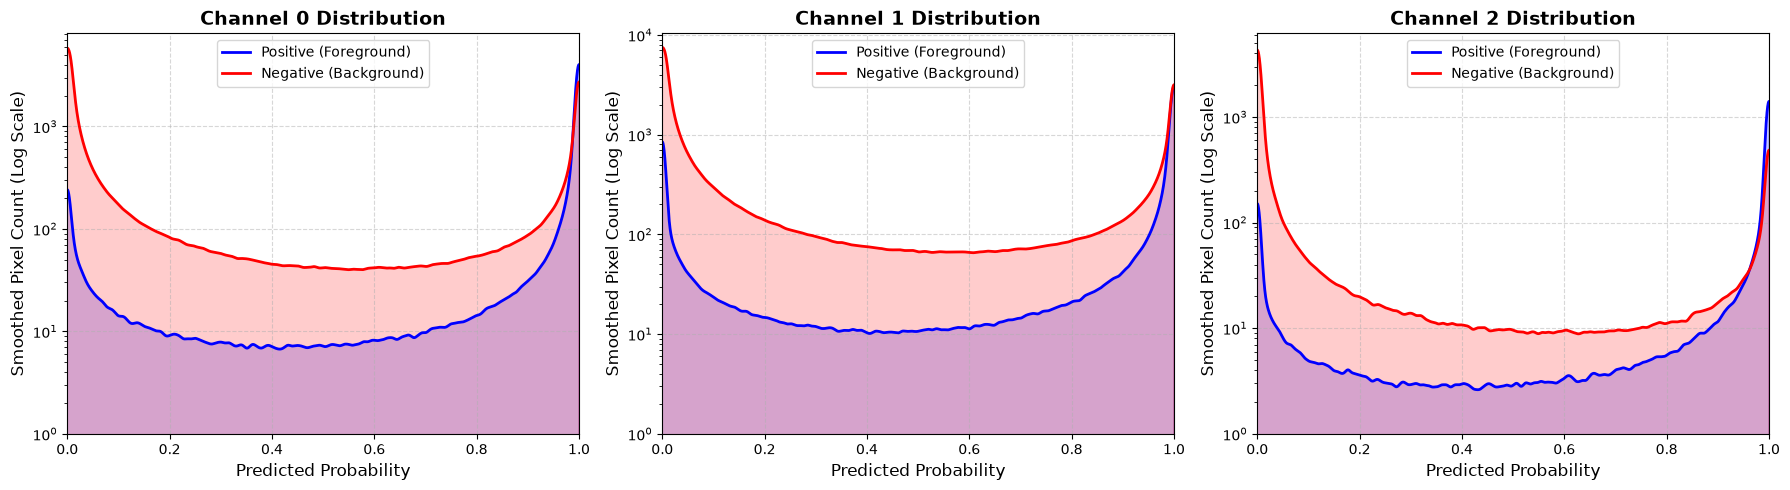

In [ ]:
state_dict_2 = torch.load('model-epoch=29-val_loss=0.42.ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_2 = {
    k[len("model."):]: v for k, v in state_dict_2.items() if k.startswith("model.")
}

main_model_2 = MRIFlexAttentionUNetGroupNorm(3,64,3,5,1,1,[5,3,3,3,3,3,3,3,3,5])
main_model_2.load_state_dict(inner_state_dict_2)

#dist_pos_2, dist_neg_2 = get_distribution(main_model_2, dataloader)

#plot_smooth_distributions(dist_pos_2, dist_neg_2)


dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

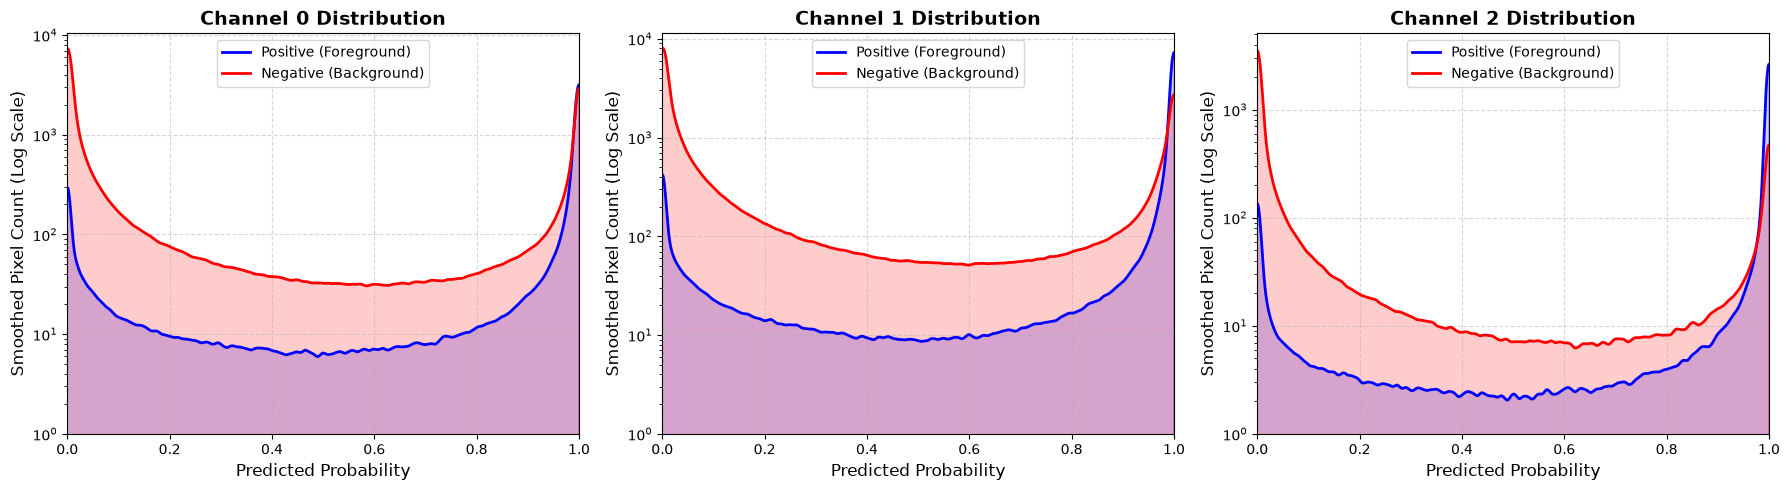

In [ ]:
state_dict_3 = torch.load('model-epoch=43-val_loss=0.37.ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_3 = {
    k[len("model."):]: v for k, v in state_dict_3.items() if k.startswith("model.")
}

main_model_3 = MRIFlexAttentionUNet(3,64,3,4,2,2,[5,3,3,5,3,3,3,3])
main_model_3.load_state_dict(inner_state_dict_3)

#dist_pos_3, dist_neg_3 = get_distribution(main_model_3, dataloader)

#plot_smooth_distributions(dist_pos_3, dist_neg_3)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

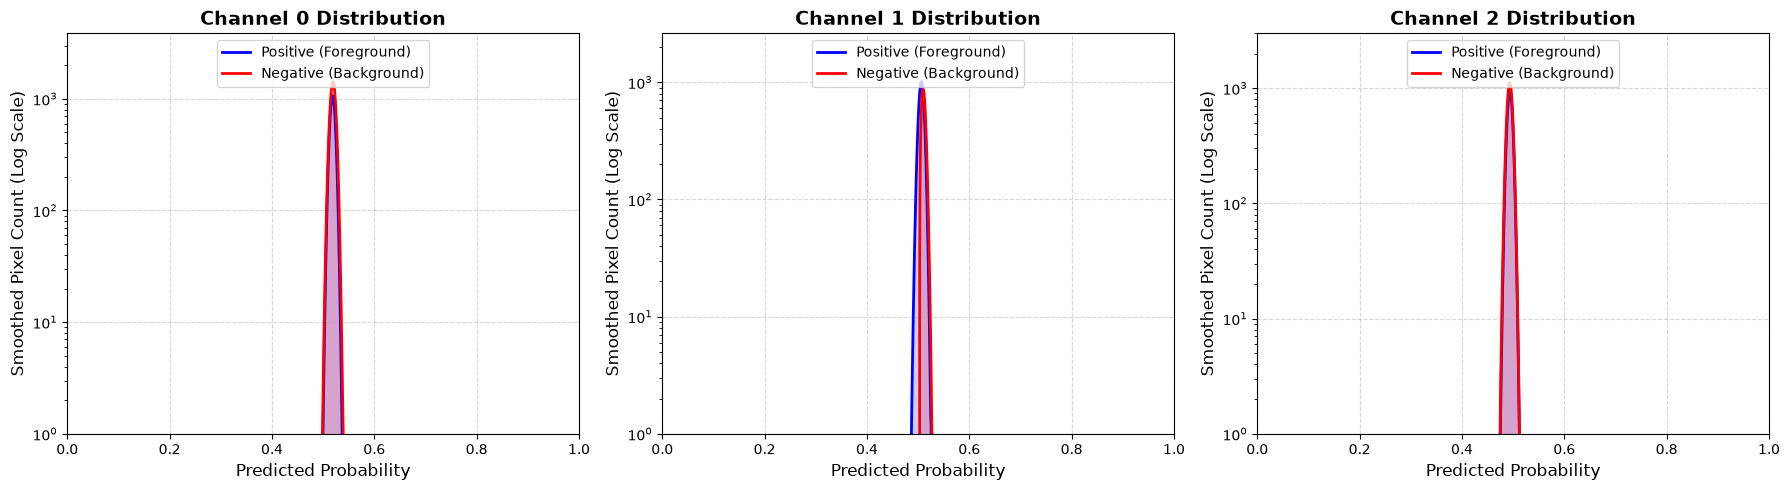

In [ ]:
state_dict_4 = torch.load('last (4).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_4 = {
    k[len("model."):]: v for k, v in state_dict_4.items() if k.startswith("model.")
}

main_model_4 = MRIFlexAttentionUNet(3,64,3,4,1,1,[5,3,3,5,3,5,3,3])
main_model.load_state_dict(inner_state_dict_4)

#dist_pos_4, dist_neg_4 = get_distribution(main_model_4, dataloader)

#plot_smooth_distributions(dist_pos_4, dist_neg_4)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

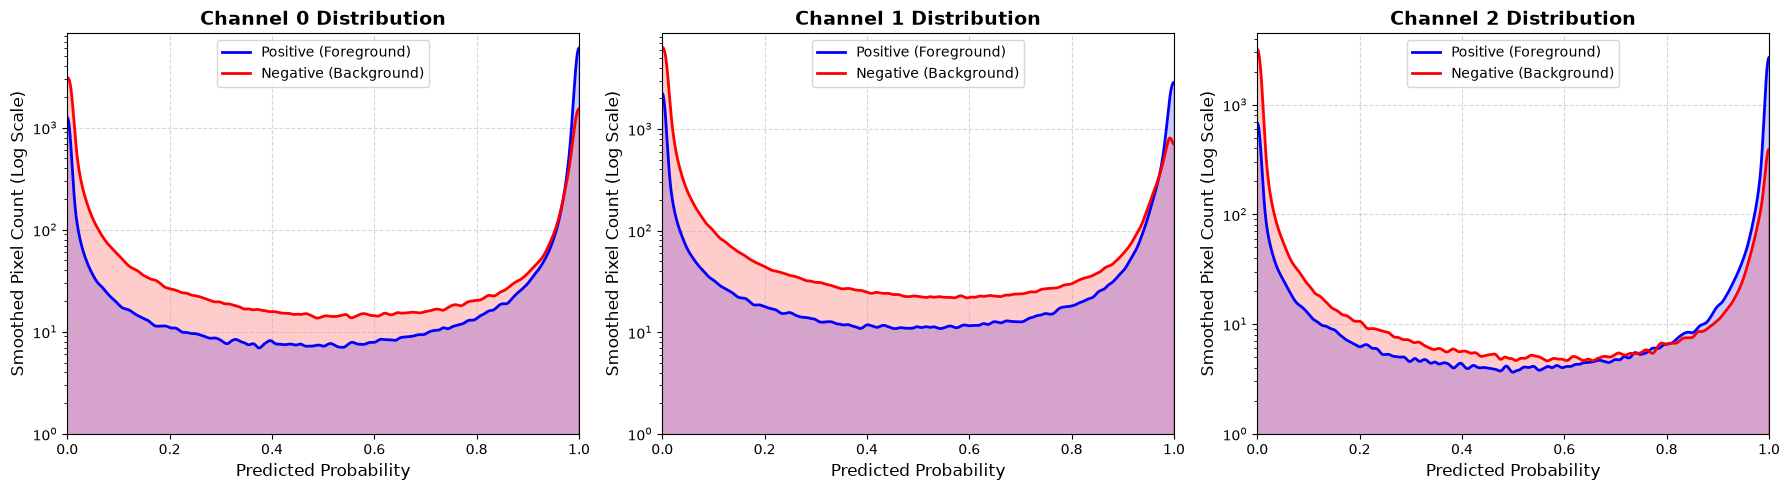

In [ ]:
state_dict_5 = torch.load('last (5).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_5 = {
    k[len("model."):]: v for k, v in state_dict_5.items() if k.startswith("model.")
}

main_model_5 = MRIFlexAttentionUNet(3,64,3,4,2,2,[5,3,3,5,3,5,5,3])
main_model_5.load_state_dict(inner_state_dict_5)

#dist_pos_5, dist_neg_5 = get_distribution(main_model_5, dataloader)

#plot_smooth_distributions(dist_pos_5, dist_neg_5)

In [107]:
torch.load('last (5).ckpt', 'cpu', weights_only=False)


{'epoch': 3,
 'global_step': 2120,
 'pytorch-lightning_version': '2.6.6',
 'state_dict': OrderedDict([('model.encoder_list.0.conv_block.conv_block.0.0.weight',
               tensor([[[[ 2.4958e-02,  7.8226e-02, -7.6603e-02, -4.2811e-02,  7.3899e-02],
                         [ 6.0279e-02,  9.1242e-02,  9.0996e-02, -1.1765e-02, -5.6208e-02],
                         [ 4.6608e-02, -1.1431e-01, -7.3340e-02,  1.1632e-01,  1.5118e-02],
                         [-6.8893e-02,  3.4278e-02, -2.4972e-02, -7.9249e-02, -1.9506e-02],
                         [ 4.4834e-02,  8.1568e-02, -2.2766e-02, -6.1573e-02,  8.9855e-02]],
               
                        [[-1.2815e-01, -6.3358e-02,  8.0464e-03,  1.4025e-02,  8.3042e-02],
                         [ 5.2272e-03,  1.0486e-02, -1.0368e-01, -9.1802e-03, -1.9259e-02],
                         [-7.0462e-02, -3.4616e-02,  5.8964e-02,  3.6361e-02,  1.0092e-01],
                         [-1.4725e-02,  8.1841e-02, -6.8524e-02, -8.6404e-02, -4.1883e-

In [122]:
np.sum(dist_neg_2, 1, dtype=np.int64)

array([1896767, 2818843,  667820])

In [267]:
dist_pos_2, dist_neg_2 = get_distribution(main_model_2, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [268]:
dist_pos_3, dist_neg_3 = get_distribution(main_model_3, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [269]:
dist_pos_4, dist_neg_4 = get_distribution(main_model_4, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [270]:
dist_pos_5, dist_neg_5 = get_distribution(main_model_5, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


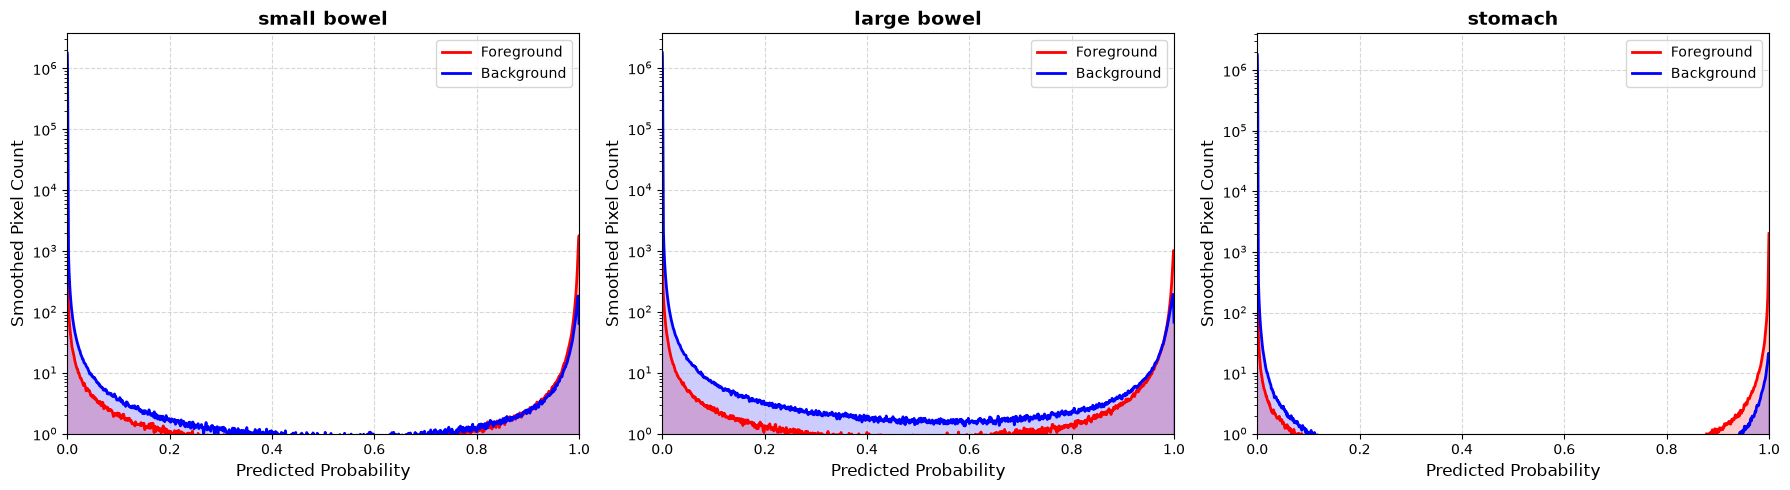

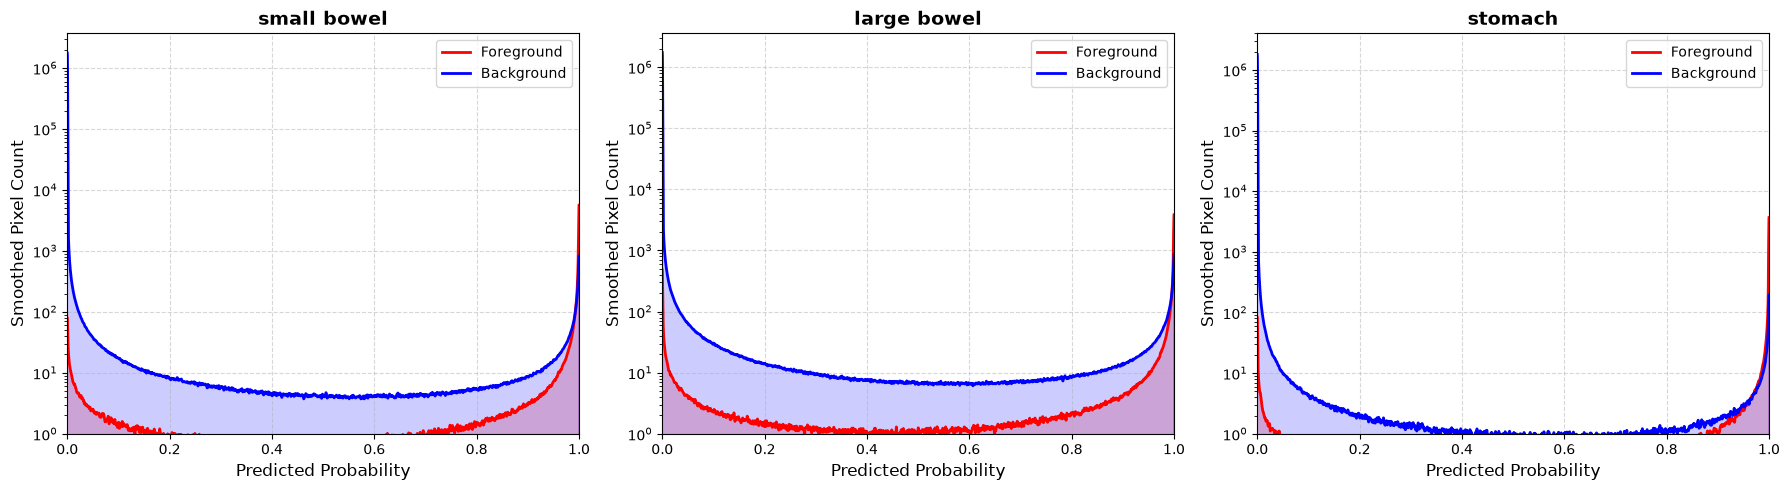

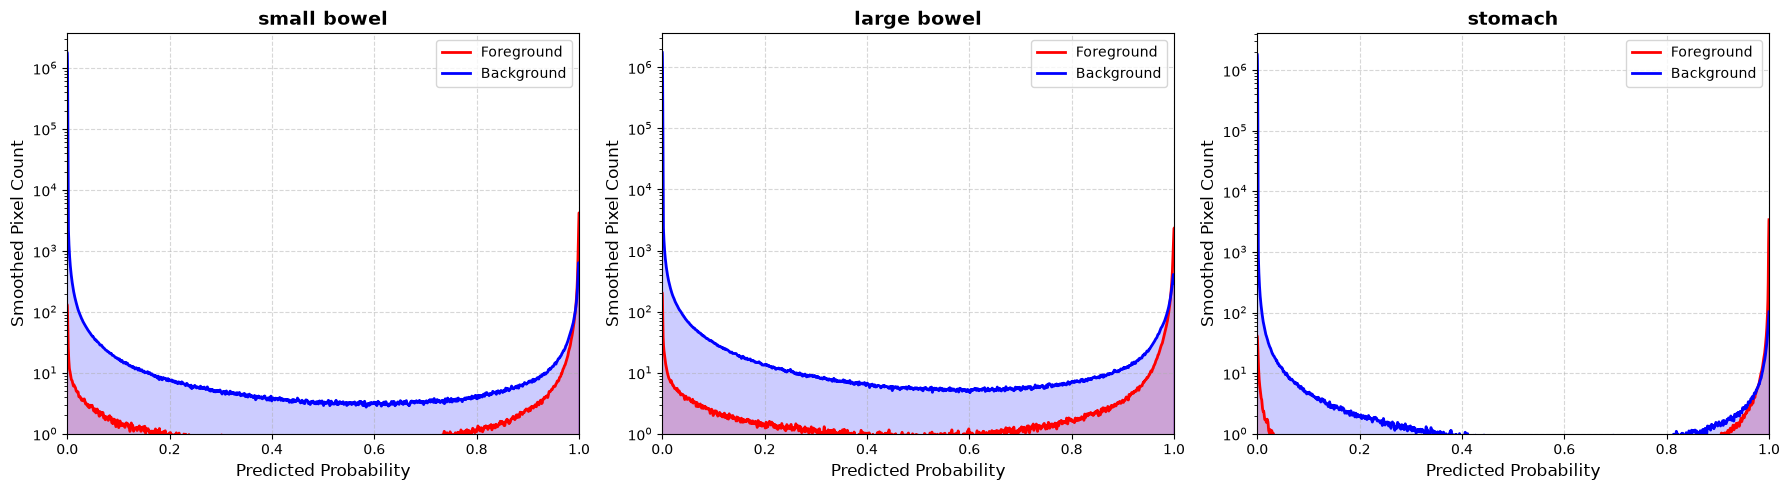

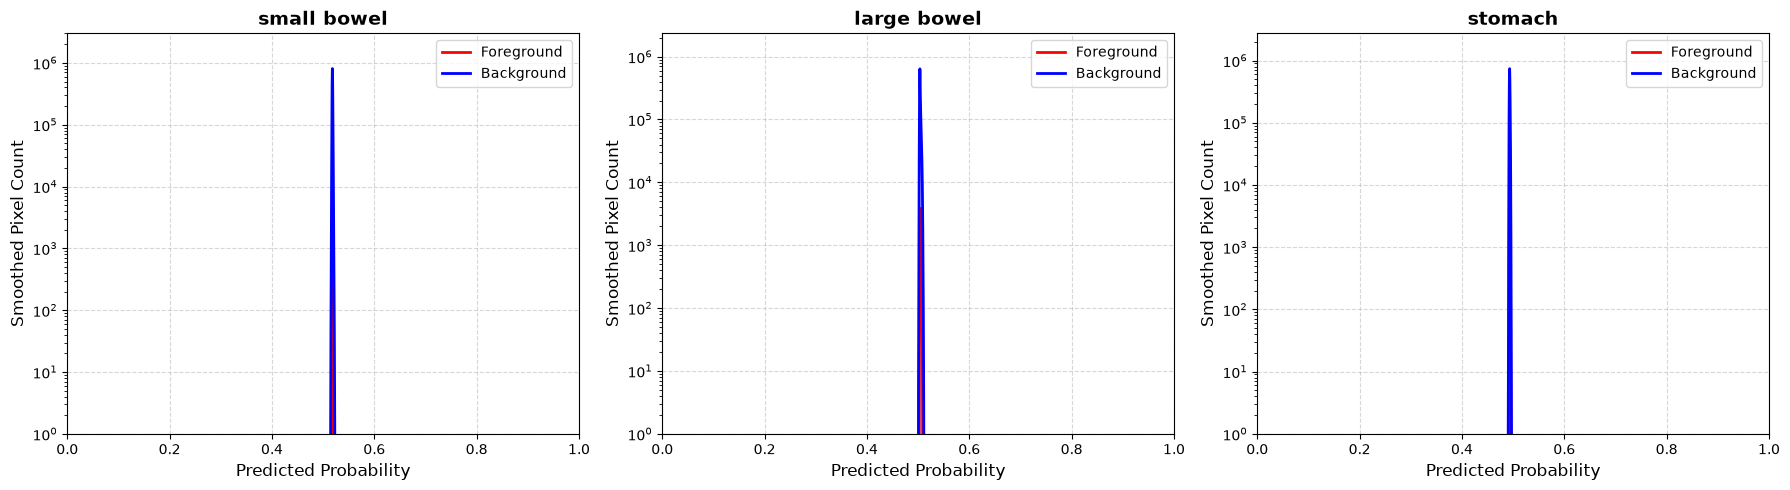

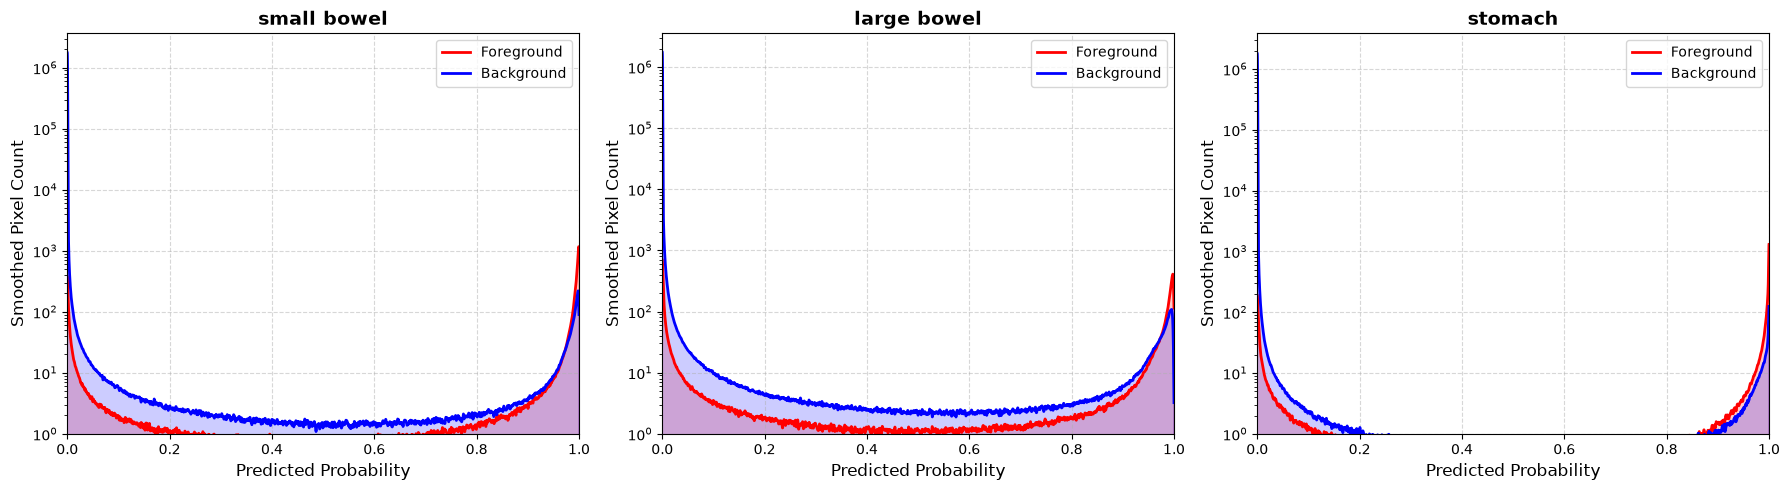

In [272]:
plot_smooth_distributions(dist_pos, dist_neg)
plot_smooth_distributions(dist_pos_2, dist_neg_2)
plot_smooth_distributions(dist_pos_3, dist_neg_3)
plot_smooth_distributions(dist_pos_4, dist_neg_4)
plot_smooth_distributions(dist_pos_5, dist_neg_5)

In [260]:
def get_partial_distribution(dist, neg_arr = False, ratio = [1,1,1]):
    ratio = np.array(ratio)
    lengths = np.sum(dist, axis=1)
    amounts_to_discard = np.round(lengths * ([1] - ratio))
    part_dist = np.copy(dist)
    if neg_arr:
        part_dist = np.flip(part_dist, 1)
    cum_sums = np.cumsum(part_dist, axis=1)
    mask_to_zero = cum_sums <= amounts_to_discard[:, None]
    
    part_dist[mask_to_zero] = 0
    if neg_arr:
        part_dist = np.flip(part_dist, 1)
    return part_dist

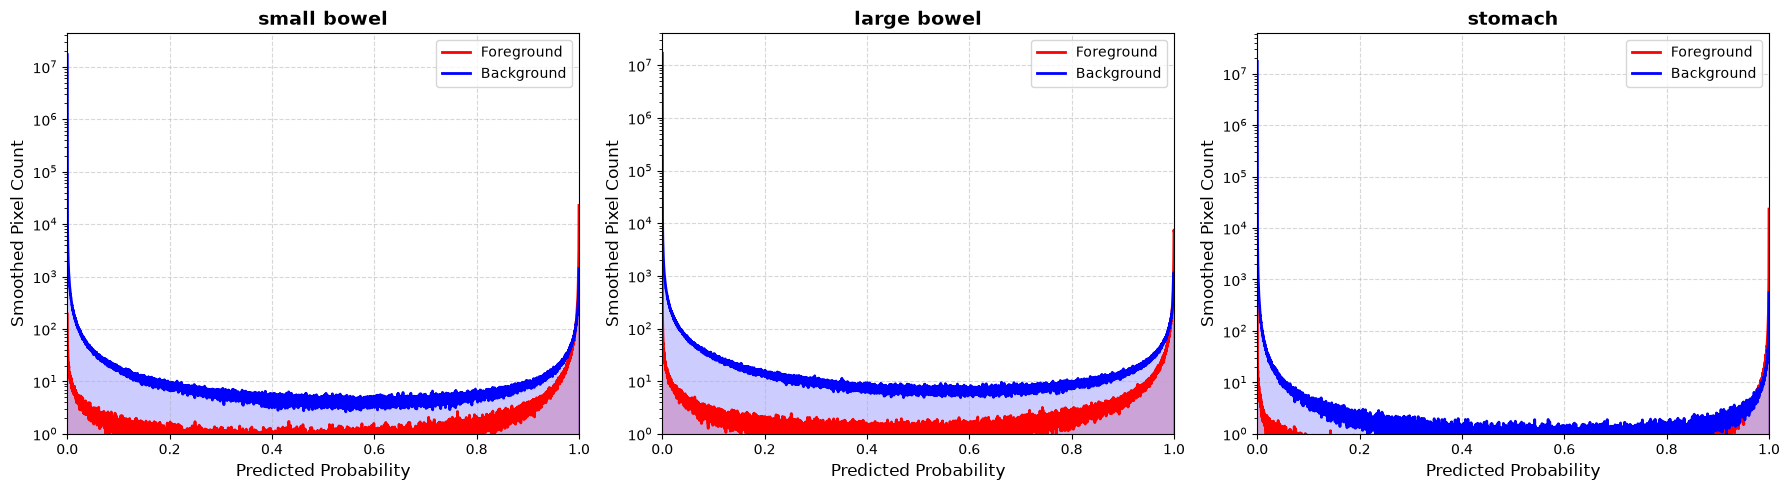

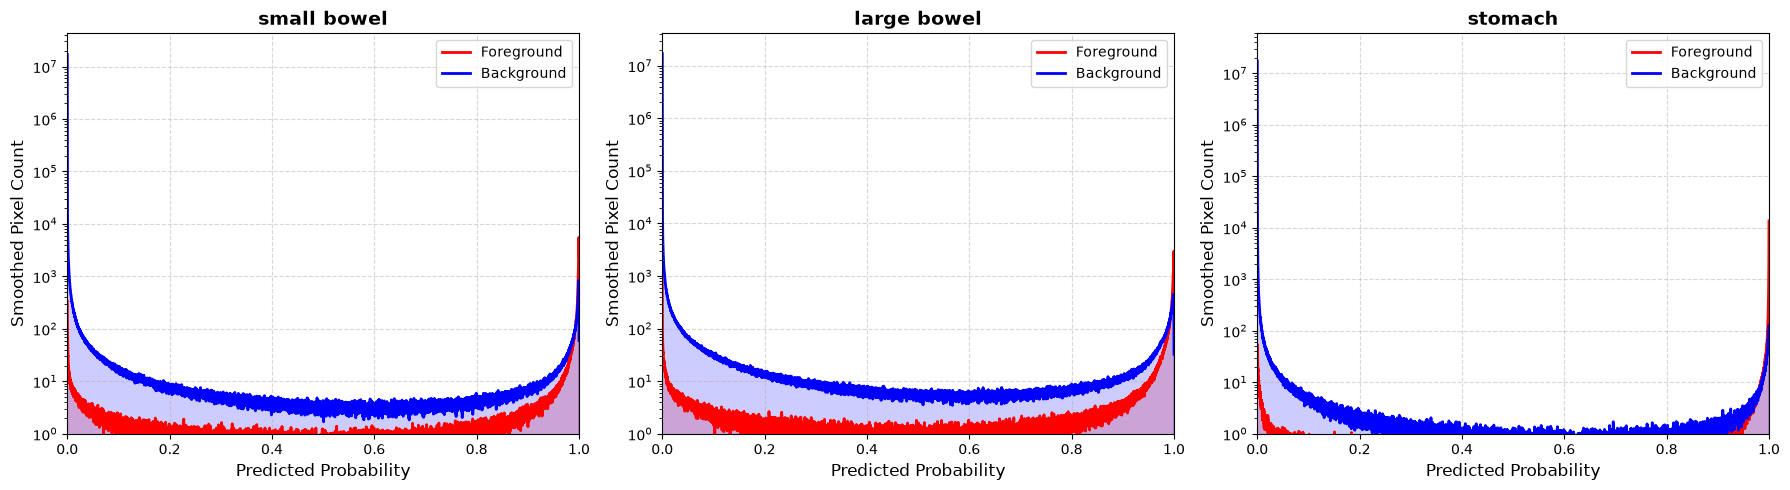

In [281]:
#plot_smooth_distributions(get_partial_distribution(dist_pos, ratio = [0.96,0.955,0.98]),   get_partial_distribution(dist_neg, neg_arr=True, ratio = [0.96,0.955,0.98]))
plot_smooth_distributions(get_partial_distribution(dist_pos_2), get_partial_distribution(dist_neg_2, neg_arr=True), 5, 0, 1)
plot_smooth_distributions(get_partial_distribution(dist_pos_3), get_partial_distribution(dist_neg_3, neg_arr=True),5, 0, 1)
#plot_smooth_distributions(get_partial_distribution(dist_pos_4, ratio = [0.96,0.955,0.98]), get_partial_distribution(dist_neg_4, neg_arr=True, ratio = [0.96,0.955,0.98]))
#plot_smooth_distributions(get_partial_distribution(dist_pos_5, ratio = [0.96,0.955,0.98]), get_partial_distribution(dist_neg_5, neg_arr=True, ratio = [0.96,0.955,0.98]))

In [315]:
def find_intersection(pos_dist, neg_dist, steps = 10,lr = 5, early_stopping = False):
    ratio = np.array([0.5, 0.5, 0.5])
    best_diff = np.array([float('inf'),float('inf'),float('inf')])
    best_ratio = np.copy(ratio)
    best_trial = np.zeros(3, int)
    best_optim_threshold = np.zeros(3)
    for i in range(steps):
        pos_part_dist = get_partial_distribution(pos_dist, ratio = ratio)
        neg_part_dist = get_partial_distribution(neg_dist, neg_arr = True,ratio = ratio)
        
        #pos_under_dist = np.sum(pos_part_dist != 0 , 1) 
        #neg_under_dist = np.sum(neg_part_dist != 0 , 1)

        pos_threshold_idx = np.argmax(pos_part_dist != 0, 1)
        neg_threshold_idx = len(pos_dist[0]) - 1 - np.argmax(np.flip(neg_part_dist != 0, 1), 1)

        #diff = len(pos_dist[0]) - pos_under_dist - neg_under_dist
        diff = pos_threshold_idx - neg_threshold_idx
        diff = np.array(diff)
        abs_diff = abs(diff)
        #optim_threshold = (len(pos_dist[0]) - pos_under_dist - diff//2)/len(pos_dist[0])
        optim_threshold = (pos_threshold_idx + neg_threshold_idx) / 2 / (len(pos_dist[0]) - 1)
        better = abs_diff < abs(best_diff)

        best_diff[better] = diff[better]
        best_ratio[better] = ratio[better]
        best_trial[better] = i
        best_optim_threshold[better] = optim_threshold[better]
        print('='*20)
        print(*[
            f'''\n----------------------------------------
            \nbest difference for {c}th channel 
            \nfalls under {best_ratio[c]*100}% distribution 
            \nrecorded at {best_trial[c]} 
            \nwith difference of {best_diff[c]} 
            ''' for c in range(len(better))])
        print('*'*50)
        print(diff)
        print(ratio)
        print('*'*50)
        if early_stopping and np.sum(better)==0: 
            break
        
        ratio+= diff/np.sum(pos_dist, 1)*lr
        ratio = np.clip(ratio, 0.01, 0.99)
        print(ratio)
    return best_ratio, best_diff, best_trial, best_optim_threshold


In [210]:
arr = len(dist_pos_3[0]) - np.sum(get_partial_distribution(dist_pos_3) != 0 , 1) - np.sum(get_partial_distribution(dist_neg_3, neg_arr=True) != 0 , 1)
arr / np.sum(dist_pos , 1) 

array([0.00042653, 0.00049696, 0.00195926])

In [191]:
np.sum(get_partial_distribution(dist_pos_3), 1)/np.sum(dist_pos_3, 1), np.sum(get_partial_distribution(dist_neg_3, neg_arr=True),1)/np.sum(dist_neg_3, 1)

(array([0.96001729, 0.94000397, 0.96502747]),
 array([0.96696828, 0.95457195, 0.97673166]))

In [194]:
get_partial_distribution(dist_neg_3, neg_arr=True) != 0

array([[ True,  True, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False]], shape=(3, 10001))

In [197]:
(dist_neg_3[:, 0] + dist_neg_3[:, 1])/np.sum(dist_neg_3, 1)

array([0.96696828, 0.96161991, 0.9864801 ])

In [254]:
arr, _, _, thresh = find_intersection(dist_pos_3, dist_neg_3, 500, 3)


----------------------------------------
            
best difference for 0th channel 
            
falls under 96.0% distribution 
            
recorded at 0 
            
with difference of 365.0 
             
----------------------------------------
            
best difference for 1th channel 
            
falls under 94.0% distribution 
            
recorded at 0 
            
with difference of 423.0 
             
----------------------------------------
            
best difference for 2th channel 
            
falls under 96.5% distribution 
            
recorded at 0 
            
with difference of 746.0 
            

----------------------------------------
            
best difference for 0th channel 
            
falls under 96.12795867927946% distribution 
            
recorded at 1 
            
with difference of 332.0 
             
----------------------------------------
            
best difference for 1th channel 
            
falls under 94.1490883756886% dist

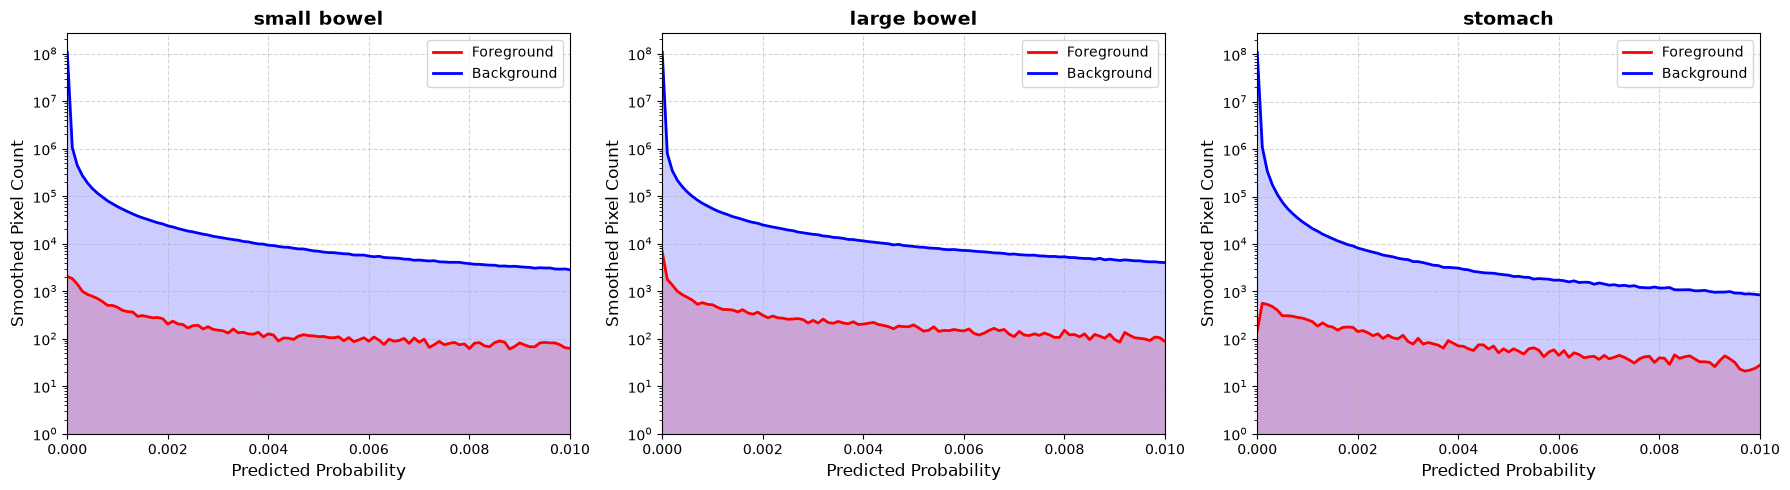

In [262]:
plot_smooth_distributions(get_partial_distribution(dist_pos_3 ), get_partial_distribution(dist_neg_3, neg_arr=True ), 0)


In [ ]:
get_partial_distribution(dist_pos_3, ratio = [0.98312722, 0.97371935, 0.96375511])/ np.sum(dist_pos_3), get_partial_distribution(dist_neg_3, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511])/np.sum(dist_neg_3,1)

In [ ]:
np.sum(get_partial_distribution(dist_pos_3, ratio = [0.98312722, 0.97371935, 0.96375511]) == 0, 1)#/np.sum(dist_pos_3, 1), 
#10001-np.sum(get_partial_distribution(dist_neg_3, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511])==0,1)#/np.sum(dist_neg_3, 1)

array([ 28,  34, 797])

In [255]:
thresh

array([0.00249975, 0.00249975, 0.04819518])

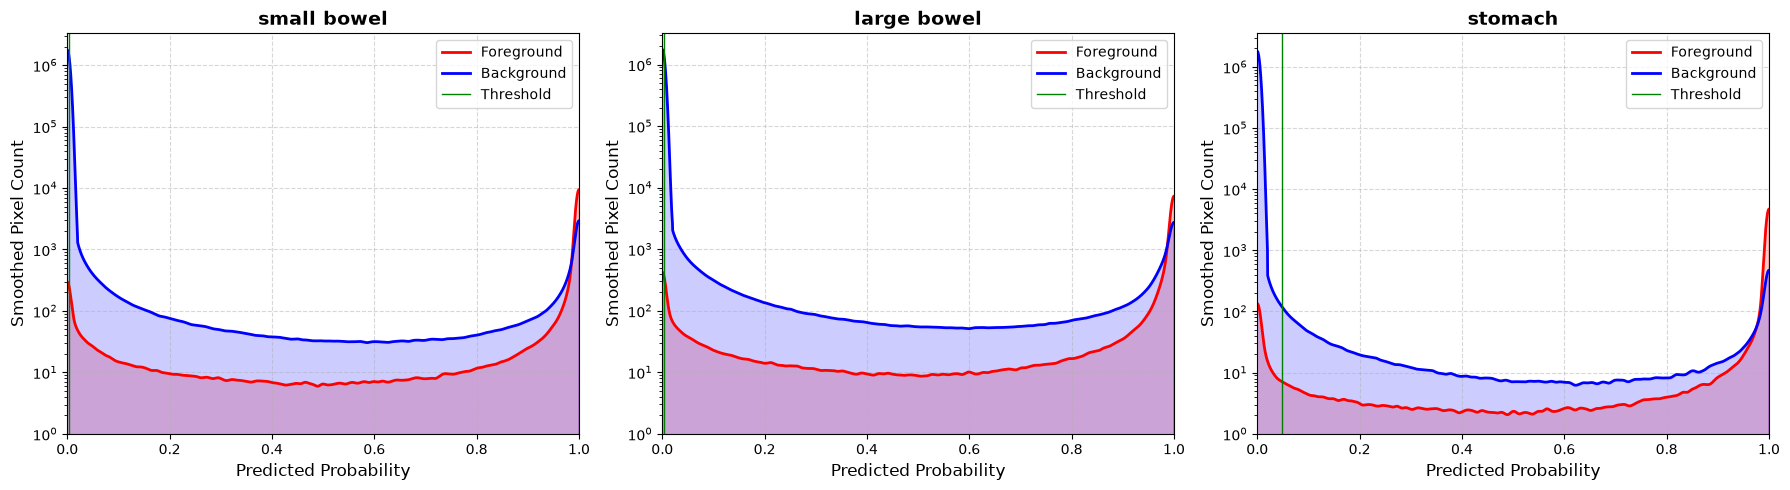

In [264]:
plot_smooth_distributions(dist_pos_3, dist_neg_3, threshold = thresh)

In [ ]:

class ThresholdCalibrator:
    def __init__(self, config, num_integ_bins = 100001, count_shift = True):
        state_dict = torch.load(config.inp_model_path, 
                                'cpu', weights_only=False)['state_dict']
        inner_state_dict = {
            k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
        }

        self.model = MRIFlexAttentionUNet( config.inp_channels,
            config.first_conv_out_channels,
            config.num_classes,
            config.depth,
            config.n_encoder_conv_layers,
            config.n_decoder_conv_layers,
            config.kernel_sizes)
        
        
        self.model.load_state_dict(inner_state_dict)

        
        dataset = MRIDataModule(TRAIN_CSV, config.dev_csv, config.test_csv, batch_size = config.batch_size, 
                                num_workers=config.num_workers, train_empty_mri_ratio= 1,
                                train_transform=v2.Compose([
                                    v2.Resize(256),
                                    v2.CenterCrop(256)
                                ]),
                                dev_transform=v2.Compose([
                                    v2.Resize(256),
                                    v2.CenterCrop(256)
                                    ]))
        
        dataset.setup()
        self.train_dataloader = dataset.train_dataloader()
        self.val_dataloader = dataset.val_dataloader()
        self.test_dataloader = dataset.test_dataloader()
        self.device = torch.device('cuda' if config.accelerator == 'gpu' else 'cpu')
        self.num_channels = config.inp_channels
        self.num_integ_bins = num_integ_bins
        self.best_ratio = np.array([0.5,0.5,0.5])
        self.count_shift = count_shift
        self.final_model_path = config.final_checkpoint



    def __call__(self):
        state_dict = torch.load(self.final_model_path, 
                                'cpu', weights_only=False)['state_dict']
        inner_state_dict = {
            k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
        }
        self.model.load_state_dict(inner_state_dict)

        dist_pos_train, dist_neg_train = self.get_distribution(self.train_dataloader)
        dist_pos_val, dist_neg_val = self.get_distribution(self.val_dataloader)
        self.dist_pos_final = dist_pos_train + dist_pos_val
        self.dist_neg_final = dist_neg_train + dist_neg_val

        self.final_best_f1_threshold, final_f1 = self.best_f1_threshold(self.dist_pos_final, self.dist_neg_final)

        
        self.threshold = self.final_best_f1_threshold
        if self.count_shift:
            self.threshold += self.final_shift


        self.dist_pos_test, self.dist_neg_test = self.get_distribution(self.test_dataloader)


        fp = np.array([np.sum(self.dist_neg_test[c, int(self.threshold*(self.num_integ_bins-1)):]) for c in range(self.num_channels)])
        fn = np.array([np.sum(self.dist_pos_test[c, :int(self.threshold*(self.num_integ_bins-1))]) for c in range(self.num_channels)])
        tp = np.array([np.sum(self.dist_pos_test[c, int(self.threshold*(self.num_integ_bins-1)):]) for c in range(self.num_channels)])
        f1 = 2*tp / (2*tp+fp+fn)




    def calc_best_thresh_and_shift(self):
        #device
        self.dist_pos_train, self.dist_neg_train = self.get_distribution(self.train_dataloader)
        self.dist_pos_val, self.dist_neg_val = self.get_distribution(self.val_dataloader)
        self.final_pos_val = self.dist_pos_train + self.dist_pos_val
        self.dist_neg_final = self.dist_neg_train + self.dist_neg_val

        self.train_best_f1_threshold, train_f1 = self.best_f1_threshold(self.dist_pos_train, self.dist_neg_train)
        self.val_best_f1_threshold, val_f1 = self.best_f1_threshold(self.dist_pos_val, self.dist_neg_val)
        if self.count_shift:
            shift = self.val_best_f1_threshold - self.train_best_f1_threshold
            self.final_shift = shift  #np.random.randn()*shift + shift

            print(train_f1, val_f1)



    def get_distribution(self, dataloader):


        dist_pos = np.zeros((self.num_channels, self.num_integ_bins), dtype=np.int64)  
        dist_neg = np.zeros((self.num_channels, self.num_integ_bins), dtype=np.int64)  
        #device------------------------------------------------------------------------------------------------------
        self.model.to(self.device)
        self.model.eval()
        with torch.no_grad():
            for i, batch in enumerate(dataloader):
                inp, mask = batch
                inp = inp.to(self.device)
                mask = mask.to(self.device)
                out = torch.sigmoid(self.model(inp))  

                for c in range(self.num_channels):
                    probs_c = out[:, c].reshape(-1)
                    mask_c = mask[:, c].reshape(-1)

                    pos_vals = probs_c[mask_c == 1]
                    neg_vals = probs_c[mask_c == 0]

                    pos_bins = (pos_vals * (self.num_integ_bins-1)).round().type(torch.int64).cpu().numpy()
                    neg_bins = (neg_vals * (self.num_integ_bins-1)).round().type(torch.int64).cpu().numpy()

                    dist_pos[c] += np.bincount(pos_bins, minlength=self.num_integ_bins)
                    dist_neg[c] += np.bincount(neg_bins, minlength=self.num_integ_bins)
                print(i)

        return dist_pos, dist_neg



    def plot_smooth_distributions(self, dist_pos = None, dist_neg = None, sigma=50, left_x_lim = 0, right_x_lim = 1, threshold = None):

        if dist_pos is None:
            dist_pos = np.copy(self.dist_pos_train)

        if dist_neg is None:
            dist_neg = np.copy(self.dist_neg_train)
        x = np.linspace(0, 1, self.num_integ_bins)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        channel_names = ['small bowel', 'large bowel', 'stomach']
        if threshold is None and self.best_threshold is not None:
            threshold = self.best_threshold
        
        for c in range(3):
            ax = axes[c]
            if sigma == 0:
                smooth_pos = dist_pos[c].astype(float)
                smooth_neg = dist_neg[c].astype(float)

            else:
                smooth_pos = gaussian_filter1d(dist_pos[c].astype(float), sigma=sigma)
                smooth_neg = gaussian_filter1d(dist_neg[c].astype(float), sigma=sigma)
            
            ax.plot(x, smooth_pos, label='Foreground', color='red', linewidth=2)
            ax.plot(x, smooth_neg, label='Background', color='blue', linewidth=2)
            if threshold is not None:
                ax.axvline(x = threshold[c], label = 'Threshold', color = 'green', linewidth = 1)
            
            ax.fill_between(x, smooth_pos, alpha=0.2, color='red')
            ax.fill_between(x, smooth_neg, alpha=0.2, color='blue')
            
            ax.set_title(f'{channel_names[c]}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Predicted Probability', fontsize=12)
            ax.set_ylabel('Smoothed Pixel Count', fontsize=12)
            
            ax.set_yscale('log')
            ax.set_xlim(left_x_lim, right_x_lim)
            
            ax.set_ylim(bottom=1) 
            
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(loc='best')
            
        plt.tight_layout()
        plt.show()




    def get_partial_distribution(self,dist_arr, neg_arr = False, ratio = [1,1,1]):

        ratio = np.array(ratio)
        part_dist = np.copy(dist_arr)
        lengths = np.sum(part_dist, axis=1)
        amounts_to_discard = np.round(lengths * ([1] - ratio))
        
        if neg_arr:
            part_dist = np.flip(part_dist, 1)
        cum_sums = np.cumsum(part_dist, axis=1)
        mask_to_zero = cum_sums <= amounts_to_discard[:, None]
        
        part_dist[mask_to_zero] = 0
        if neg_arr:
            part_dist = np.flip(part_dist, 1)
        return part_dist



    def find_intersection(self,pos_dist, neg_dist, steps = 10, lr = 5, early_stopping = False):
        
        if self.best_ratio is not None:
            ratio = self.best_ratio
        else:
            ratio = np.array([0.5,0.5,0.5])
        best_diff = np.array([float('inf'),float('inf'),float('inf')])
        best_ratio = ratio
        
        best_trial = np.zeros(3, int) 
        
        best_threshold = np.zeros(3)
        for i in range(steps):
            pos_part_dist = self.get_partial_distribution(pos_dist, ratio = ratio)
            neg_part_dist = self.get_partial_distribution(neg_dist, neg_arr = True,ratio = ratio)
            
            #pos_under_dist = np.sum(pos_part_dist != 0 , 1) 
            #neg_under_dist = np.sum(neg_part_dist != 0 , 1)
    
            pos_threshold_idx = np.argmax(pos_part_dist != 0, 1)
            neg_threshold_idx = self.num_integ_bins - 1 - np.argmax(np.flip(neg_part_dist != 0, 1), 1)
    
            #diff = len(pos_dist[0]) - pos_under_dist - neg_under_dist
            diff = pos_threshold_idx - neg_threshold_idx
            diff = np.array(diff)
            abs_diff = abs(diff)
            #optim_threshold = (len(pos_dist[0]) - pos_under_dist - diff//2)/len(pos_dist[0])
            optim_threshold = (pos_threshold_idx + neg_threshold_idx) / 2 / (self.num_integ_bins - 1)
            better = abs_diff < abs(best_diff)

            best_diff[better] = diff[better]
            best_ratio[better] = ratio[better]
            best_trial[better] = i
            best_threshold[better] = optim_threshold[better]
            print('='*20)
            print(*[
                f'''\n----------------------------------------
                \nbest difference for {c}th channel 
                \nfalls under {best_ratio[c]*100}% distribution 
                \nrecorded at {best_trial[c]} 
                \nwith difference of {best_diff[c]} 
                ''' for c in range(len(better))])

            if early_stopping and np.sum(better)==0: 
                break

            ratio+= diff / (self.num_integ_bins - 1)*lr
            ratio = np.clip(ratio, 0.01, 0.99)

            self.best_ratio = best_ratio
        return best_ratio, best_diff, best_trial, best_threshold
         



    def tpr_tnr_crossing(self, dist_pos, dist_neg):
        total_pos = dist_pos.sum(axis=1, keepdims=True)
        total_neg = dist_neg.sum(axis=1, keepdims=True)

        tp = np.cumsum(dist_pos[:, ::-1], axis=1)[:, ::-1]  
        tn = np.cumsum(dist_neg, axis=1)                      

        tpr = tp / total_pos
        tnr = tn / total_neg

        diff = np.abs(tpr - tnr)
        best_bin = np.argmin(diff, axis=1)
        best_threshold = best_bin / (dist_pos.shape[1] - 1)
        return best_threshold



    def best_f1_threshold(self, dist_pos, dist_neg):
        
        tp = np.cumsum(dist_pos[:, ::-1], axis=1)[:, ::-1]
        fp = np.cumsum(dist_neg[:, ::-1], axis=1)[:, ::-1]
        total_pos = dist_pos.sum(axis=1, keepdims=True)
        fn = total_pos - tp

        f1 = 2*tp / (2*tp + fp + fn)

        best_bin = np.argmax(f1, axis=1)
        best_f1 = f1[np.arange(self.num_channels), best_bin]
        best_threshold = best_bin / (self.num_integ_bins - 1)

        return best_threshold, best_f1

 






In [316]:
arr, _, _, thresh = find_intersection(dist_pos_3, dist_neg_3, 1000, 3)


----------------------------------------
            
best difference for 0th channel 
            
falls under 50.0% distribution 
            
recorded at 0 
            
with difference of 99876.0 
             
----------------------------------------
            
best difference for 1th channel 
            
falls under 50.0% distribution 
            
recorded at 0 
            
with difference of 99603.0 
             
----------------------------------------
            
best difference for 2th channel 
            
falls under 50.0% distribution 
            
recorded at 0 
            
with difference of 99966.0 
            
**************************************************
[99876 99603 99966]
[0.5 0.5 0.5]
**************************************************
[0.85013702 0.85105554 0.99      ]

----------------------------------------
            
best difference for 0th channel 
            
falls under 85.01370151154842% distribution 
            
recorded at 1 
          

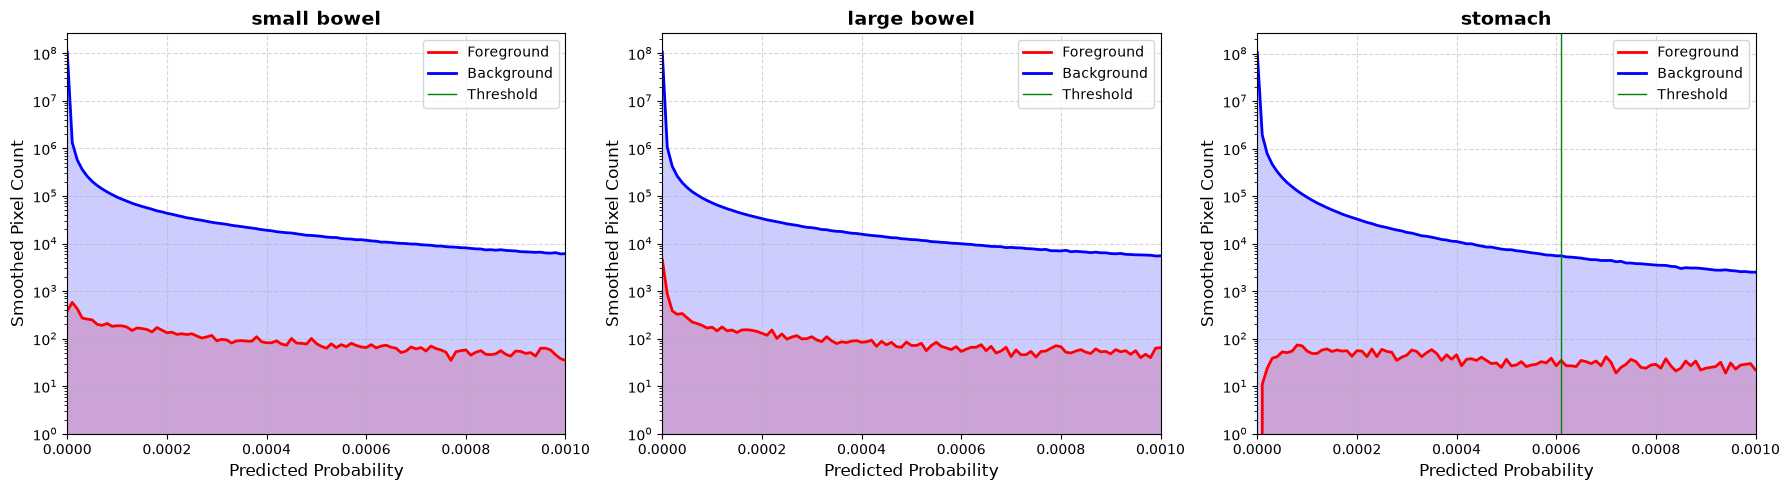

In [404]:
plot_smooth_distributions(get_partial_distribution(dist_pos_3), get_partial_distribution(dist_neg_3, neg_arr=True), 0, 0, 0.001, b)

In [347]:
fn = np.array([np.sum(dist_neg_3[c, ((thresh[c]+0.3) * 100000).astype(np.int64):]) for c in range(3)])
fn/108/16

array([359.2806713 , 525.984375  ,  68.71527778])

In [20]:
dist_neg_8 == dist_neg_7

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(3, 100001))

In [18]:
best_f1 = np.array([0.,0.,0.])
best_margin = np.array([0,0,0])
for margin in range(100000):
    
    fn = np.array([np.sum(dist_neg_8[c, margin:]) for c in range(3)])
    tn = np.array([np.sum(dist_neg_8[c, :margin ]) for c in range(3)])
    fp = np.array([np.sum(dist_pos_8[c, :margin]) for c in range(3)])
    tp = np.array([np.sum(dist_pos_8[c, margin:]) for c in range(3)])
    f1 = 2*tp / (2*tp+fp+fn)

    better = f1 > best_f1
    best_f1[better] = f1[better]
    best_margin[better] = margin

    if margin % 1000 == 0:
        print(margin)

    


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


NameError: name 'best_margin' is not defined

In [421]:
recall = tp/(tp+fp)
recall

array([0.809809  , 0.72473046, 0.8839992 ])

In [422]:
2*precision*recall/(precision+recall)

array([0.74983499, 0.67115247, 0.85902525])

In [19]:
#model 3: array([0.75012434, 0.67125403, 0.85990471])
#model 5: array([0.72200597, 0.60817839, 0.74532207])
#model 6:array([0.73799434, 0.63684366, 0.86069368])
#model 7: array([0.74427382, 0.63764027, 0.85896458])
best_f1

array([0.74427382, 0.63764027, 0.85896458])

In [ ]:
#model 3: array([0.97895, 0.97407, 0.95494])
#model 5: array([0.64712, 0.39348, 0.13012])
#model 6: array([98275, 97892, 97143])
#model 7: array([0.98162, 0.97652, 0.96529])
best_margin/100000

array([0.98162, 0.97652, 0.96529])

In [398]:
def tpr_tnr_crossing(pos_dist, neg_dist):
    total_pos = pos_dist.sum(axis=1, keepdims=True)
    total_neg = neg_dist.sum(axis=1, keepdims=True)

    tp = np.cumsum(pos_dist[:, ::-1], axis=1)[:, ::-1]   # sum from bin t to end
    tn = np.cumsum(neg_dist, axis=1)                      # sum from 0 to bin t

    tpr = tp / total_pos
    tnr = tn / total_neg

    diff = np.abs(tpr - tnr)
    best_bin = np.argmin(diff, axis=1)
    best_threshold = best_bin / (pos_dist.shape[1] - 1)
    return best_threshold, tpr, tnr

In [400]:
b, _, __ =tpr_tnr_crossing(dist_pos_3, dist_neg_3)

In [401]:
_

array([[1.00000000e+00, 9.99552437e-01, 9.98875833e-01, ...,
        1.95268450e-03, 5.46891890e-04, 2.92143103e-05],
       [1.00000000e+00, 9.94601567e-01, 9.93571225e-01, ...,
        1.64126447e-03, 5.12234293e-04, 3.99448761e-05],
       [1.00000000e+00, 1.00000000e+00, 9.99971110e-01, ...,
        1.50639780e-01, 1.05907720e-01, 4.52258139e-02]],
      shape=(3, 100001))

In [403]:
b == thresh

array([ True,  True, False])

In [429]:
from src.entity.config_entity import SelectedModelsCreationEntity

In [467]:
calibrator_1 = ThresholdCalibrator(SelectedModelsCreationEntity(7777))

In [452]:
dist_pos_6, dist_neg_6 = calibrator_1.get_distribution(calibrator_1.val_dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


NameError: name 'calibrator_2' is not defined

In [4]:
from src.entity.config_entity import FinalModelCreationEntity
from src.components.final_train.calibrator import ThresholdCalibrator
calibrator_2 = ThresholdCalibrator(FinalModelCreationEntity('last (6).ckpt'))
calibrator_3 = ThresholdCalibrator(FinalModelCreationEntity('model-epoch=34-val_loss=0.35.ckpt'))

d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
dist_pos_7, dist_neg_7 = calibrator_2.get_distribution(calibrator_2.val_dataloader)
dist_pos_8, dist_neg_8 = calibrator_3.get_distribution(calibrator_3.val_dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

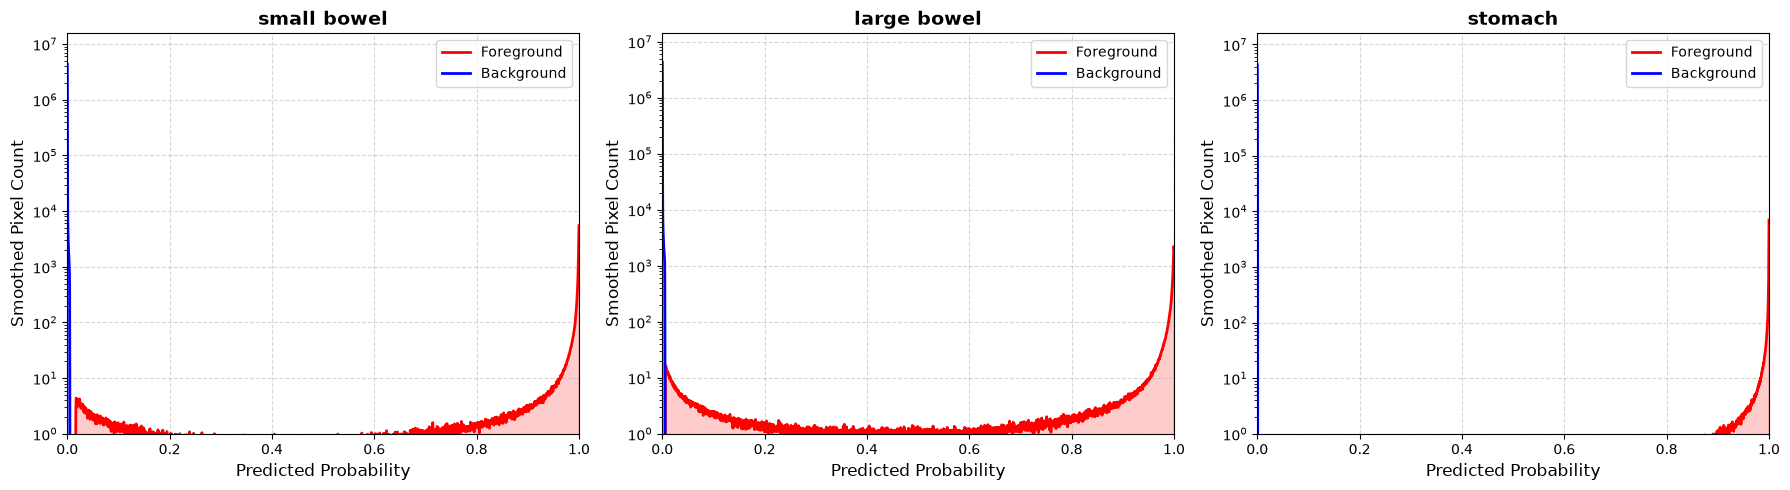

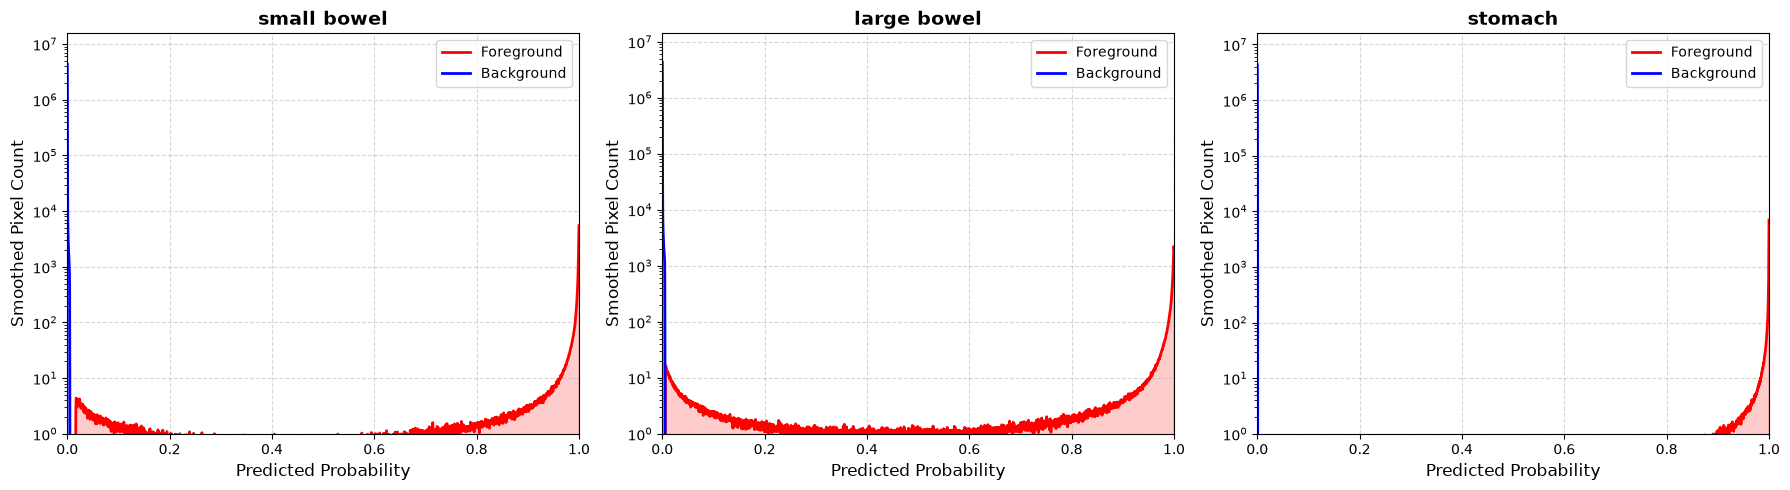

In [13]:
ratio = [0.98312722, 0.97371935, 0.96375511]
#! threshold problem
import numpy as np
import matplotlib.pyplot as plt
plot_smooth_distributions(calibrator_2.get_partial_distribution(dist_pos_7, ratio = ratio), calibrator_2.get_partial_distribution(dist_neg_7, neg_arr=True, ratio = ratio), 20)
plot_smooth_distributions(calibrator_3.get_partial_distribution(dist_pos_8, ratio = ratio), calibrator_3.get_partial_distribution(dist_neg_8, neg_arr=True, ratio = ratio), 20)

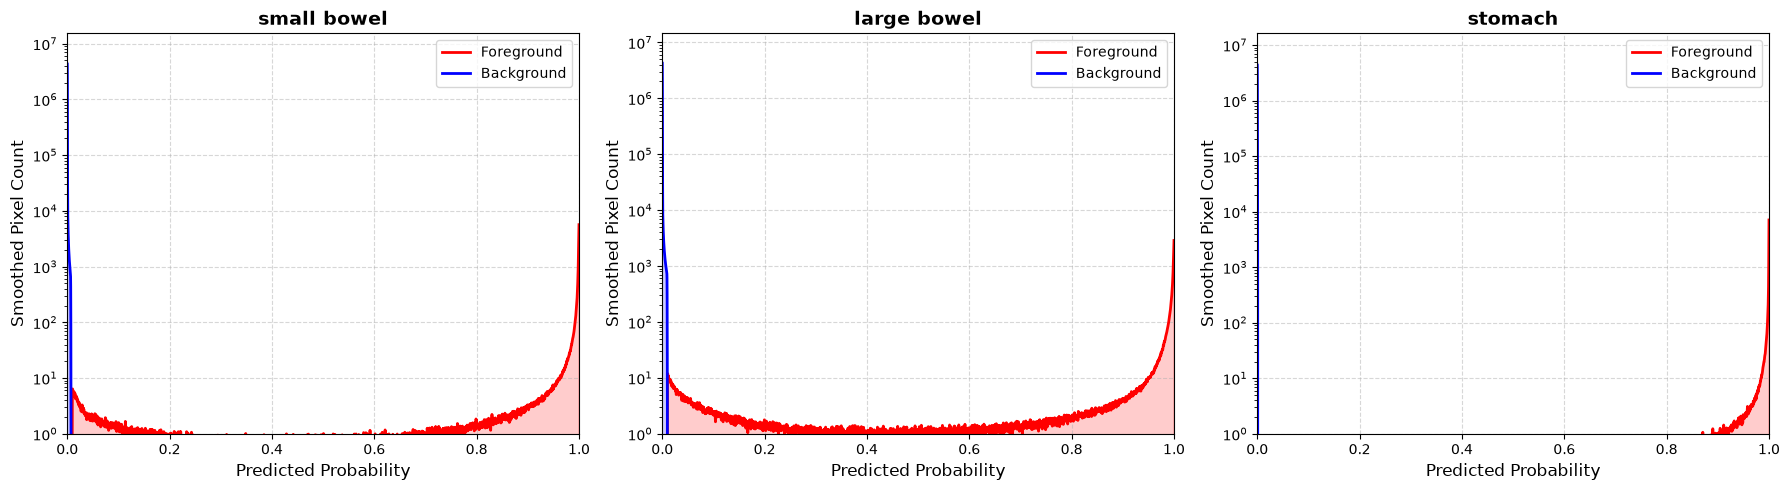

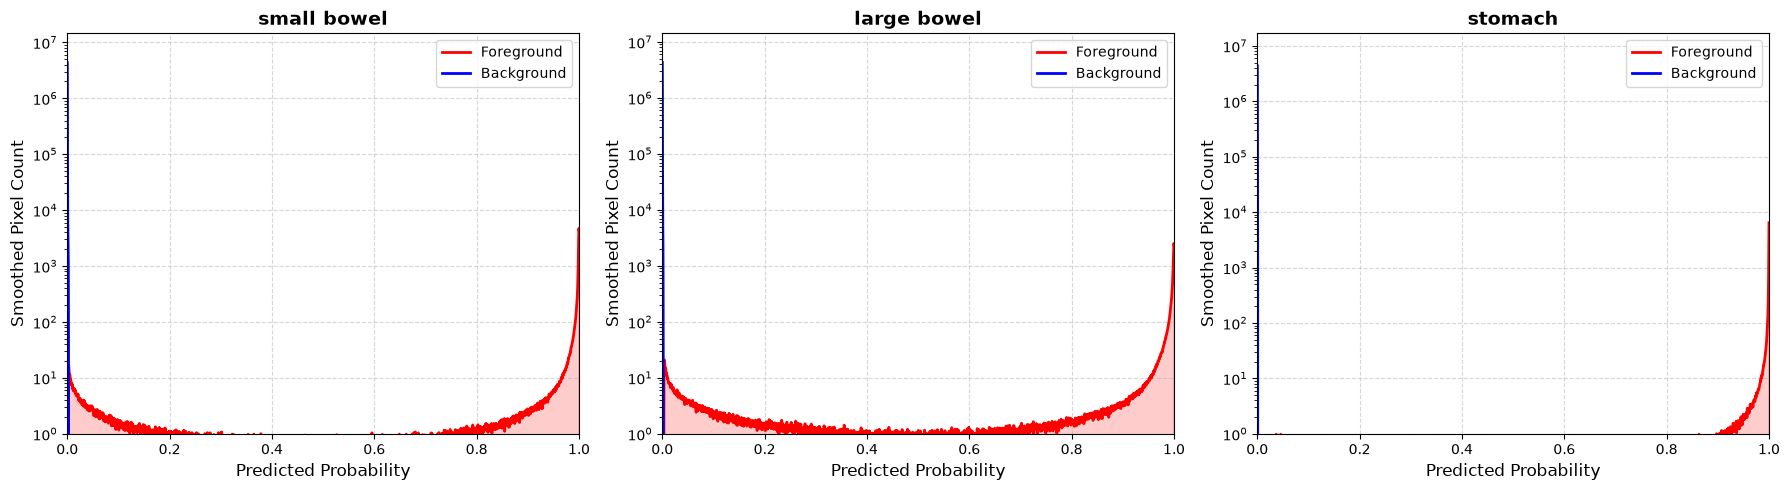

In [ ]:
ratio = [0.98312722, 0.97371935, 0.96375511]
plot_smooth_distributions(get_partial_distribution(dist_pos_6, ratio = ratio ), get_partial_distribution(dist_neg_6, neg_arr=True, ratio = ratio ), 20)
plot_smooth_distributions(get_partial_distribution(dist_pos_3, ratio = ratio), get_partial_distribution(dist_neg_3, neg_arr=True, ratio = ratio), 20)


In [457]:
best_f1 = np.array([0.,0.,0.])
best_margin = np.array([0,0,0])
for margin in range(100000):
    
    fn = np.array([np.sum(dist_neg_6[c, margin:]) for c in range(3)])
    tn = np.array([np.sum(dist_neg_6[c, :margin ]) for c in range(3)])
    fp = np.array([np.sum(dist_pos_6[c, :margin]) for c in range(3)])
    tp = np.array([np.sum(dist_pos_6[c, margin:]) for c in range(3)])
    f1 = 2*tp / (2*tp+fp+fn)

    better = f1 > best_f1
    best_f1[better] = f1[better]
    best_margin[better] = margin

    if margin % 1000 == 0:
        print(margin)

    


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


In [27]:
calibrator_2.tpr_tnr_crossing(dist_pos_7, dist_neg_7)

array([0.01094, 0.00568, 0.0018 ])

In [459]:
best_margin

array([98275, 97892, 97143])

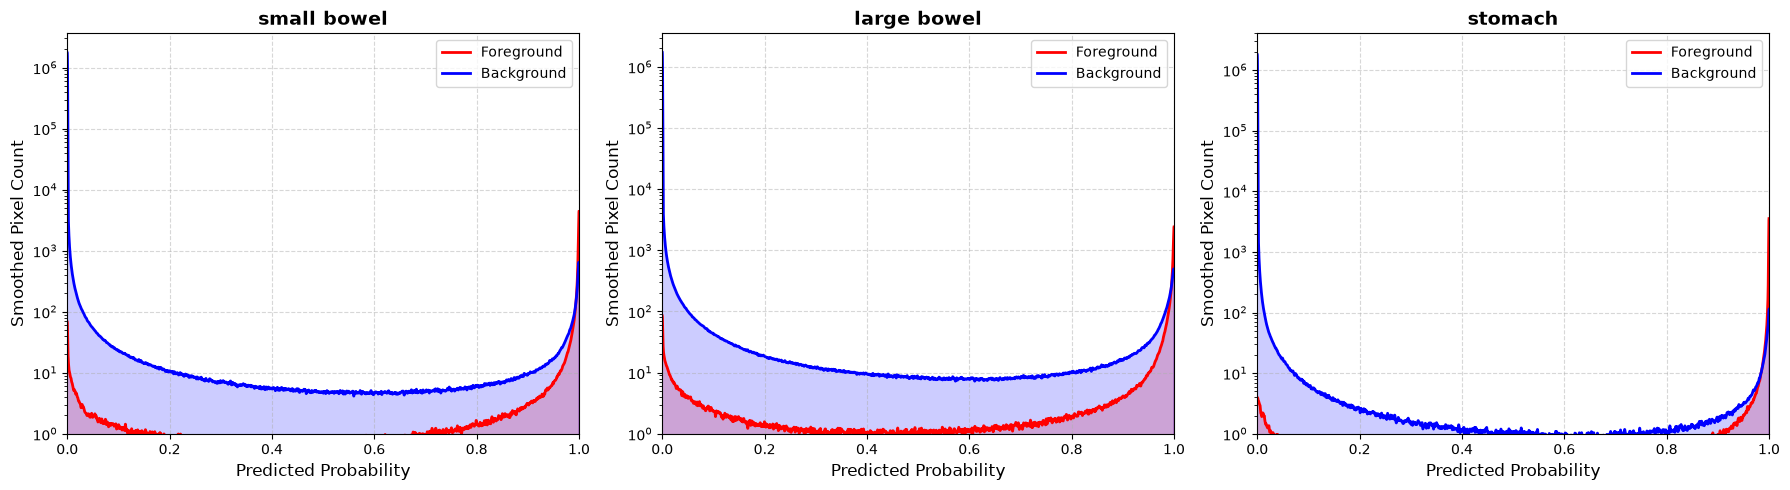

In [468]:
calibrator_1.plot_smooth_distributions(dist_pos_6, dist_neg_6)

In [470]:
calibrator_1.get_partial_distribution(dist_neg_6, ratio = [0.9,0.9,0.9])

array([[103333566,   1651891,    673662, ...,        75,        45,
                0],
       [103309939,   1019074,    445660, ...,        34,         1,
                0],
       [105915475,   1676262,    718972, ...,        46,        33,
                3]], shape=(3, 100001))

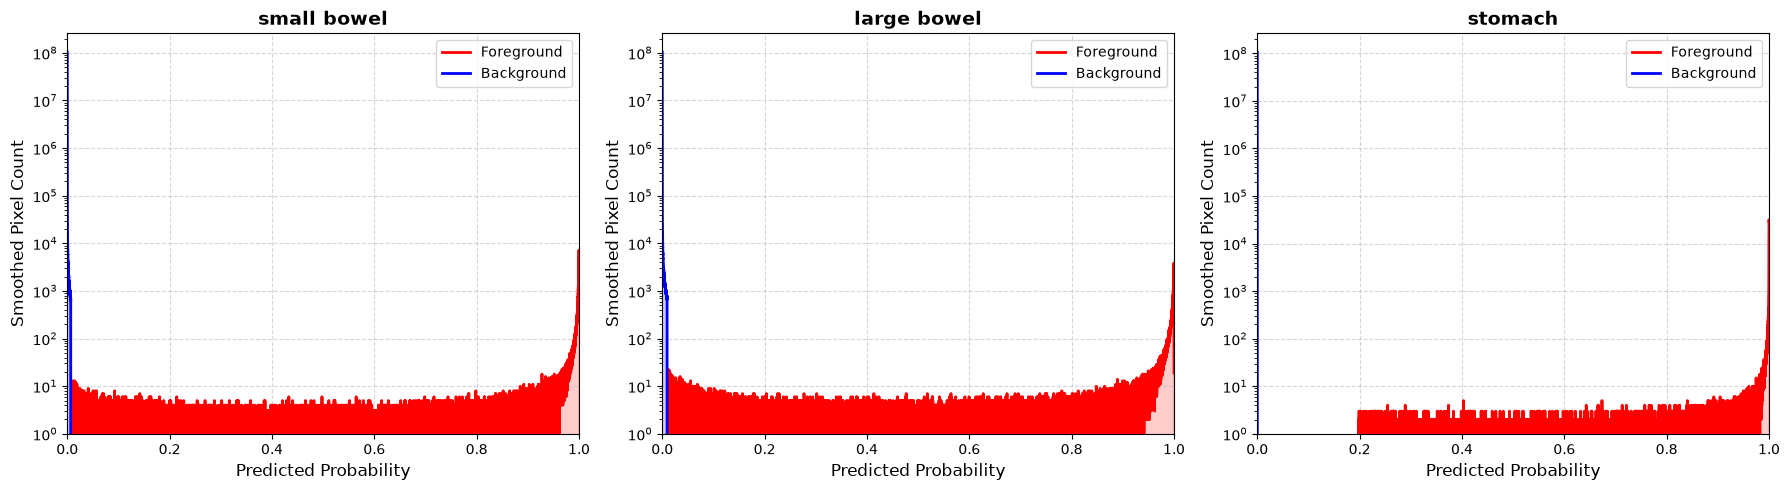

In [472]:
calibrator_1.plot_smooth_distributions(calibrator_1.get_partial_distribution(dist_pos_6, ratio = ratio), calibrator_1.get_partial_distribution(dist_neg_6, neg_arr=True, ratio = ratio), 0)

In [473]:
inner_state_dict = {
            k: v for k, v in state_dict.items() if not k.startswith("model.")
        }

In [475]:
state_dict

{'model.encoder_list.0.conv_block.conv_block.0.0.weight': tensor([[[[ 6.9056e-02,  8.0692e-02, -4.6694e-02,  5.8558e-02, -8.1674e-02],
           [ 2.5590e-02, -3.0480e-02,  8.1494e-02,  8.9239e-02, -1.1357e-01],
           [ 9.8038e-02,  5.4199e-02,  1.2188e-01,  3.6727e-02,  3.7565e-02],
           [-3.1433e-02,  1.0591e-01,  5.2521e-02, -2.7615e-02,  1.4522e-02],
           [-9.1596e-02, -2.8927e-02, -4.7922e-02,  6.7152e-02, -1.1690e-01]],
 
          [[-6.3212e-02, -5.9403e-02, -1.0851e-01, -4.3711e-02, -1.5981e-01],
           [ 1.1723e-01, -8.9195e-02,  6.9006e-02, -1.8246e-02, -7.6668e-02],
           [ 1.0327e-01,  6.1893e-02,  1.2271e-01,  1.9968e-02, -6.0781e-02],
           [ 7.0479e-02,  3.5912e-02,  1.1655e-01,  1.4501e-01,  6.6108e-02],
           [-3.2778e-02,  1.1062e-01,  7.3288e-02,  9.7511e-02, -5.8147e-02]],
 
          [[-1.5053e-01, -1.1004e-01, -1.6938e-01,  6.6210e-03, -3.4610e-02],
           [ 2.2465e-02, -2.1415e-02, -9.1756e-02, -9.2821e-03, -1.6102e-01],
 

In [25]:
#last (6).ckpt
#model-epoch=34-val_loss=0.35.ckpt
state_dict = torch.load('last (7).ckpt',#!config.inp_checkpoint, 
                        'cpu', weights_only=False)

In [ ]:
[k for k, v in state_dict.items()]

['epoch',
 'global_step',
 'pytorch-lightning_version',
 'state_dict',
 'loops',
 'callbacks',
 'optimizer_states',
 'lr_schedulers',
 'hparams_name',
 'hyper_parameters']

In [26]:
state_dict['epoch']

34

In [ ]:
self.first_conv_out_channels = hparams['first_conv_out_channels']
self.depth = hparams['depth']
self.n_encoder_conv_layers = hparams['n_encoder_conv_layers']
self.n_decoder_conv_layers = hparams['n_decoder_conv_layers']
self.kernel_sizes = hparams['kernel_sizes']
self.empty_mri_ratio = 0.1
self.lr = hparams['learning_rate']
self.w = hparams['weight_decay']